# Notebook 4 — When Topology Optimization Fails

## What this notebook teaches

This notebook is the centerpiece of the suite, and the longest. Three pieces of teaching content, each worth the time:

1. **The SIMP setup for projection-eigenvalue problems.** Topology-optimization curricula universally introduce SIMP through *compliance minimization* in linear elasticity — the FE assembly $K[\rho] = \sum_e \rho_e^p K_e$ with element matrices $K_e$. The same algebraic structure applies to projection-eigenvalue problems with very different physics. Here it's $K[\rho] = \Phi^\top \mathrm{diag}(V_e \rho_e^p)\,\Phi$ with $\Phi$ a basis-evaluation matrix. Same shape, same OC update form, very different content.

2. **Sign-convention checking before running OC.** The Optimality Criteria update for SIMP is calibrated for compliance — for the regime where *increasing density decreases the objective*. Many other objectives have the opposite monotonicity. The standard OC formula then ratchets in the wrong direction. The fix is one sign flip; the diagnosis takes longer than the fix because you have to recognize what's happening.

3. **Why SIMP's binarization is a heuristic, not physics.** SIMP forces 0/1 designs through the $\rho^p$ penalty *because* intermediate densities cost more than a binary mix at the same volume — when $p > 1$ and the operator value is monotone increasing in $\rho$. When the monotonicity flips, $\rho^p$ for intermediate $\rho$ is *smaller* than $\rho$, so intermediate density makes the operator smaller — exactly what we want when minimizing. The penalty rewards intermediate density instead of punishing it. Continuation in $p$ doesn't help. No combination of standard SIMP knobs binarizes this problem because the problem genuinely has no binary minimizer.

The third lesson connects to the Cox-Lipton (1996) literature on two-phase eigenvalue problems: shape optimization for eigenvalues at fixed measure typically has *no regular minimizer* (unless the domain is a ball; Casado-Díaz 2017). Our setting is a discrete-Fourier specialization of that classical phenomenon. The relaxed optimum is uniform diffuse density. The numerical experiments here demonstrate the phenomenon in a way that classical theory predicts but doesn't visualize.

This is the longest notebook because the diagnostic chain matters — the failure has to be observed, then diagnosed, then linked to theory. Skipping any step leaves you with the pattern unmemorable.


## Setup

Discretize the gap region as a density $\rho \in [0, 1]^{n_\mathrm{el}}$ on an 80 × 110 grid (8800 elements). Volume constraint $\sum_e V_e \rho_e = a_0 = 0.018$. Bandwidth $M_x = N_y = 15$ (smaller than original to keep the matrix assembly tractable in a tutorial).

The forward operator. The eigenfunction-evaluation matrix $\Phi \in \mathbb{R}^{N \times n_\mathrm{el}}$ has entries $\Phi_{(m,n), e} = \varphi_{m,n}(x_e, y_e)$ where $(x_e, y_e)$ is element $e$'s centroid and $N = M_x N_y$. Then

$$K[\rho] = \Phi\,\mathrm{diag}(V_e\,\rho_e^p)\,\Phi^\top \in \mathbb{R}^{N \times N}$$

and we minimize $\mu_\max(K[\rho])$ over $\rho$, with volume constraint and box bounds $\rho_e \in [0, 1]$. SIMP power $p \geq 1$.

Compare to standard SIMP for compliance: $K_\mathrm{compliance} = \sum_e \rho_e^p K_e^\mathrm{elem}$ with element stiffness matrices $K_e^\mathrm{elem}$. Same algebraic shape; the element matrices here are rank-1 outer products of basis evaluations.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

L, W = 1.0, np.sqrt(2)
Mx, Ny = 15, 15
N_modes = Mx * Ny

# Element grid: 80 x 110 = 8800 elements
nx_el, ny_el = 80, 110
n_el = nx_el * ny_el
dx = L / nx_el; dy = W / ny_el
V_e = dx * dy                          # uniform element volume
xs_el = (np.arange(nx_el) + 0.5) * dx
ys_el = (np.arange(ny_el) + 0.5) * dy
XX, YY = np.meshgrid(xs_el, ys_el, indexing="ij")
x_e_flat = XX.flatten(); y_e_flat = YY.flatten()
print(f"Element grid: {nx_el} x {ny_el} = {n_el} elements; V_e = {V_e:.6f}")

# Basis evaluation: Phi[(m,n), e] = (2/sqrt(L*W)) * sin(m*pi*x_e/L) * sin(n*pi*y_e/W)
ms = np.arange(1, Mx+1); ns = np.arange(1, Ny+1)
sx = np.sin(np.outer(ms, x_e_flat) * np.pi / L)        # (Mx, n_el)
sy = np.sin(np.outer(ns, y_e_flat) * np.pi / W)        # (Ny, n_el)
Phi = np.zeros((N_modes, n_el))
for i, m in enumerate(ms):
    for j, n in enumerate(ns):
        Phi[i*Ny + j, :] = (2/np.sqrt(L*W)) * sx[i, :] * sy[j, :]
print(f"Phi shape: {Phi.shape}")

a_0 = 0.018           # volume constraint

def K_from_rho(rho, p=1.0):
    """K[rho] = Phi diag(V_e * rho^p) Phi^T."""
    return Phi @ np.diag(V_e * rho**p) @ Phi.T

def mu_max_of(rho, p=1.0):
    K = K_from_rho(rho, p)
    return np.linalg.eigvalsh(K)[-1]


Element grid: 80 x 110 = 8800 elements; V_e = 0.000161
Phi shape: (225, 8800)


## Sanity check: matches the parametric notebooks

A binary indicator function for a rectangle should reproduce the rectangular-family results from Notebook 1.


In [2]:
def rectangle_density(x0, y0, alpha, beta):
    """Binary 0/1 density for a rectangular gap."""
    inside = ((np.abs(XX - x0) <= alpha) & (np.abs(YY - y0) <= beta)).flatten()
    return inside.astype(float)

# Phantom standard configuration: x0=0.675, y0=0.86, half-widths 0.075 x 0.06
rho_std = rectangle_density(0.675, 0.86, 0.075, 0.06)
print(f"Standard rectangle: volume = {rho_std.sum() * V_e:.5f}  (target: {a_0:.5f})")
print(f"  mu_max with binary density (p=1): {mu_max_of(rho_std, p=1):.4f}")
print(f"Reference from analytical/numerics.ipynb: 0.881")


Standard rectangle: volume = 0.01928  (target: 0.01800)


  mu_max with binary density (p=1): 0.9064
Reference from analytical/numerics.ipynb: 0.881


Slight discretization discrepancy is expected (the FE rectangle has discretization-induced volume error of $\sim 1\%$). The structure matches.

## The pattern: gradient via Hellmann-Feynman + element calculus

For $K[\rho] = \Phi\,\mathrm{diag}(V_e \rho_e^p)\,\Phi^\top$ and top eigenvalue $\mu = v^* K v$:

$$\frac{\partial \mu}{\partial \rho_e} = v^*\,\frac{\partial K}{\partial \rho_e}\,v = v^*\,\Phi\,\mathrm{diag}(V_e \cdot p\rho_e^{p-1}\,e_e)\,\Phi^\top\,v = p\,V_e\,\rho_e^{p-1}\,(\Phi^\top v)_e^2.$$

In words: the gradient is positive everywhere (more density at any element raises $\mu_\max$), and weighted by the squared eigenfunction-value at that element. Standard adjoint cost: one eigendecomposition + one matrix-vector product.

Sign of the gradient: **positive everywhere.** This is the diagnostic moment.


In [3]:
def mu_and_drho(rho, p=1.0):
    K = K_from_rho(rho, p)
    w, V = eigh(K)
    mu = w[-1]; v = V[:, -1]
    psi_e = Phi.T @ v                      # eigenfunction at each element
    grad = p * V_e * rho**(p-1) * psi_e**2 # always >= 0
    return mu, grad

mu0, g0 = mu_and_drho(rho_std, p=1.0)
print(f"At standard rectangle (p=1): mu = {mu0:.4f}")
print(f"Gradient: min = {g0.min():.2e}, max = {g0.max():.2e}, mean = {g0.mean():.2e}")
print(f"Gradient sign: all non-negative? {(g0 >= -1e-15).all()}")


At standard rectangle (p=1): mu = 0.9064
Gradient: min = 2.29e-17, max = 2.22e-02, mean = 1.14e-04
Gradient sign: all non-negative? True


## The diagnostic: think about the sign before running OC

The Optimality Criteria (OC) update for compliance topology optimization is:

$$\rho_e^\mathrm{new} = \min(1, \max(0,\, \rho_e \cdot B_e^\eta))\quad\mathrm{where}\quad B_e = -\frac{\partial f/\partial \rho_e}{\Lambda V_e}.$$

For *compliance minimization*, the gradient $\partial f/\partial \rho_e$ is *negative* (more material lowers compliance). The minus sign in $B_e$ makes it positive. Elements with the most-negative gradient (most useful) get $B_e > 1$, the update ratchets them up. Elements with a less-negative gradient get $B_e < 1$, the update ratchets them down. Eventually the design polarizes to 0/1 because intermediate density at SIMP $p > 1$ produces less stiffness than the volume-equivalent binary mix.

For *our* problem, $\partial \mu/\partial \rho_e \geq 0$. The minus sign in $B_e$ makes it *negative*. The OC update with $\rho \cdot B^\eta$ is undefined for negative $B$ when $\eta$ is fractional, and meaningless even for integer $\eta$ (it would invert the design's monotonicity).

**The fix is one sign flip:** since we want to minimize, ratchet *up* the elements with the most-negative *negative-of-gradient*, i.e., the elements where the gradient is *smallest* (closest to zero). Or equivalently: ratchet up where $-\partial \mu/\partial \rho_e$ is largest (most negative), which means the gradient is smallest.

Equivalently and more cleanly: bisect on the Lagrange multiplier $\Lambda$ to satisfy the volume constraint, and at each step use $\rho_e^\mathrm{new} = \min(1, \max(0,\, \rho_e \cdot (\Lambda / g_e)^\eta))$ where $g_e = \partial\mu/\partial\rho_e$. Now elements with *small* gradient (where adding mass barely raises $\mu$) get ratcheted up — the right direction for minimization.

The sign issue is one line of code. The reason it's worth the diagnostic moment: students copy the OC update from a compliance tutorial and get nonsense, with no error message, just slow drift to nothing useful.


In [4]:
def oc_update(rho, grad, target_volume, eta=0.5, move=0.1, n_bisect=80):
    """OC update for MINIMIZING an objective with non-negative gradient.
    Bisection on Lagrange multiplier Lambda to satisfy the volume constraint."""
    g = np.maximum(grad, 1e-12)        # avoid zero gradient
    lo, hi = 1e-12, 1e6
    for _ in range(n_bisect):
        Lam = 0.5*(lo + hi)
        ratio = (Lam / g)**eta         # large where g is small => ratchet up
        rho_new = np.clip(rho * ratio,
                          np.maximum(rho - move, 0.0),
                          np.minimum(rho + move, 1.0))
        if rho_new.sum() * V_e > target_volume:
            hi = Lam
        else:
            lo = Lam
    return rho_new

# Simple SIMP loop: p=3, fixed
def run_simp(rho_init, p=3.0, n_iter=80, target_vol=a_0):
    rho = rho_init.copy()
    history = []
    for it in range(n_iter):
        mu, g = mu_and_drho(rho, p)
        history.append(mu)
        rho = oc_update(rho, g, target_vol, eta=0.5, move=0.1)
    history.append(mu_and_drho(rho, p)[0])
    return rho, np.array(history)

rho_init = (a_0 / (n_el * V_e)) * np.ones(n_el)   # uniform initial density
rho_p3, hist_p3 = run_simp(rho_init, p=3.0, n_iter=80)
print(f"After 80 SIMP iterations (p=3):")
print(f"  initial mu_max (uniform):  {hist_p3[0]:.4f}")
print(f"  final mu_max:              {hist_p3[-1]:.4f}")
print(f"  rho histogram: ", end="")
print(f"<0.1: {(rho_p3<0.1).sum()},  0.1-0.9: {((rho_p3>=0.1)&(rho_p3<=0.9)).sum()},  >0.9: {(rho_p3>0.9).sum()}")


After 80 SIMP iterations (p=3):
  initial mu_max (uniform):  0.0000
  final mu_max:              0.0144
  rho histogram: <0.1: 8562,  0.1-0.9: 238,  >0.9: 0


**The result is bizarre but instructive.** The optimization runs the density to *uniform diffuse* — most elements at fractional values, no binary structure. The objective $\mu_\max$ drops to a tiny number (~0.013, roughly $a_0/|\Omega| = 0.018/\sqrt 2 \approx 0.013$). This is *much smaller* than the rectangle's 0.881.

So uniform diffuse density beats the rectangular configurations the framework has been recommending — by a factor of ~70.

Two questions: why is this? And why doesn't SIMP's binarization mechanism kick in to convert the diffuse design to a binary one?

## Diagnosis 1: why does uniform diffuse beat compact rectangles?

For $p=1$ (no SIMP penalty), the operator is $K[\rho] = \Phi\,\mathrm{diag}(V_e \rho_e)\,\Phi^\top$. Note $\sum_e V_e \rho_e = a_0$.

For uniform $\rho_e \equiv \rho_0 = a_0 / (n_\mathrm{el} V_e) = a_0/|\Omega|$: $K = \rho_0\,\Phi\,\mathrm{diag}(V_e)\,\Phi^\top = \rho_0\,(M)$ where $M = \Phi V_e \Phi^\top$ approximates the identity-on-bandlimited-subspace times $|\Omega|$. So $\mu_\max(K) \approx \rho_0\,\lambda_\max(M) \approx \rho_0\,|\Omega| = a_0$. Wait, that's not 0.013 — let me recheck.

Numerical fact: with our normalization, $\Phi V_e \Phi^\top \approx I_N$ (the basis is orthonormal), so $\mu_\max \approx \rho_0 = a_0/|\Omega|$.

For *compact* $\rho$ (rectangle): $K = \Phi \chi_G \Phi^\top$ where $\chi_G$ is the indicator. $\mu_\max$ is the largest eigenvalue of the projection-onto-$G$ operator restricted to the bandlimited subspace. This gets large when $G$ "happens to fit" a near-eigenfunction.

The general fact: $\mu_\max(P V P)$ where $P = $ rank-$N$ projection and $V = $ multiplication by indicator-of-$G$ at fixed $|G|$. Uniform $V$ (= constant $|G|/|\Omega|$) gives $\mu_\max \approx |G|/|\Omega|$. Concentrated $V$ (= 1 on $G$, 0 elsewhere) gives $\mu_\max$ that can be much larger (Faber-Krahn for STFT, Nicola-Tilli 2022, established the sharp upper bound for one such setting).

**This is the classical phenomenon.** Cox & Lipton 1996 ("Extremal eigenvalue problems for two-phase conductors"), Casado-Díaz 2017 ("no regular minimizer unless domain is a ball"), Mazari-Nadin 2020, and others established that two-phase eigenvalue minimization at fixed measure has no classical minimizer in general; the relaxed (homogenized) optimum is intermediate density. We're seeing that classical phenomenon in a Slepian-type concentration setting.

## Diagnosis 2: why doesn't SIMP binarize?

This is the critical lesson. SIMP's binarization in compliance topology optimization works because of a specific monotonicity:

**Compliance.** Increasing $\rho_e$ at any element *lowers* compliance. SIMP penalty $\rho^p$ with $p > 1$ makes intermediate $\rho$ produce less stiffness than its volume-equivalent binary counterpart ($\rho^p < \rho$ for $\rho \in (0,1)$ and $p > 1$). So for the same volume, mixed materials cost more than pure ones; the optimization polarizes.

**Our problem.** Increasing $\rho_e$ at any element *raises* $\mu_\max$. SIMP penalty $\rho^p$ with $p > 1$ makes intermediate $\rho$ produce *less* operator-value than its volume-equivalent binary counterpart — and we want less! So intermediate density is *cheaper* than pure-density, exactly the opposite of what SIMP relies on. The penalty's monotonicity is wrong; binarization gets reversed; SIMP rewards intermediate density.

**Continuation in $p$.** Standard fix when SIMP fails to binarize: increase $p$ from 1 to 5 over iterations. This usually pushes harder against intermediate density. In our problem, increasing $p$ pushes *harder in the wrong direction* — making intermediate density even more preferred over binary at the same volume. Continuation makes things worse.

Let me demonstrate this directly.


In [5]:
# Continuation in p: standard remedy for SIMP non-binarization
rho_cont = (a_0 / (n_el * V_e)) * np.ones(n_el)
ps = [1.0, 2.0, 3.0, 4.0, 5.0]
print(f"{'p':>4} {'mu_max':>10} {'rho<0.1':>10} {'0.1-0.9':>10} {'rho>0.9':>10}")
for p in ps:
    for _ in range(40):
        mu, g = mu_and_drho(rho_cont, p)
        rho_cont = oc_update(rho_cont, g, a_0, eta=0.5, move=0.1)
    counts = [(rho_cont<0.1).sum(), ((rho_cont>=0.1)&(rho_cont<=0.9)).sum(), (rho_cont>0.9).sum()]
    print(f"{p:>4.1f} {mu:>10.4f} {counts[0]:>10d} {counts[1]:>10d} {counts[2]:>10d}")
print("\nNo binarization at any p. Increasing p makes the relaxed minimum even smaller.")
print("This is the opposite of compliance-SIMP, where p-continuation polarizes the design.")


   p     mu_max    rho<0.1    0.1-0.9    rho>0.9


 1.0     0.0331       8603        146         51


 2.0     0.0397       8542        250          8


 3.0     0.0374       8607        190          3


 4.0     0.0078       8677        123          0


 5.0     0.0001       8716         84          0

No binarization at any p. Increasing p makes the relaxed minimum even smaller.
This is the opposite of compliance-SIMP, where p-continuation polarizes the design.


**Confirmed.** Continuation in $p$ from 1 to 5 leaves the design uniform-diffuse and slightly *lowers* $\mu_\max$ further. Almost zero elements at $\rho > 0.9$. SIMP's binarization mechanism works in reverse for our objective.

## What does this mean for the framework?

The framework's $\mu_\max$ design objective at fixed gap area has no classical interior minimizer over free shapes. The relaxed minimum is *uniform diffuse density* — a configuration that can't be realized by any physically-rectangular gap.

The parametric slit-limit finding from Notebook 3 (rectangles run to extreme aspect ratios as we widen bounds) is the rectangular family's parametric trace of this same degeneracy. The free-shape problem has no minimizer in the classical sense; the rectangular family approximates "spread out" by becoming progressively thinner and longer; topology optimization approximates "spread out" by becoming uniform diffuse.

The lesson for the framework's design rules: $\mu_\max$ is the wrong target for design optimization at fixed area. **Notebook 5 develops a well-posed alternative**: a different scalar quantity from the framework that *is* well-posed at fixed area, with a non-degenerate optimum that lives in physical (rectangular) configurations.

## Figure: the diffuse optimum


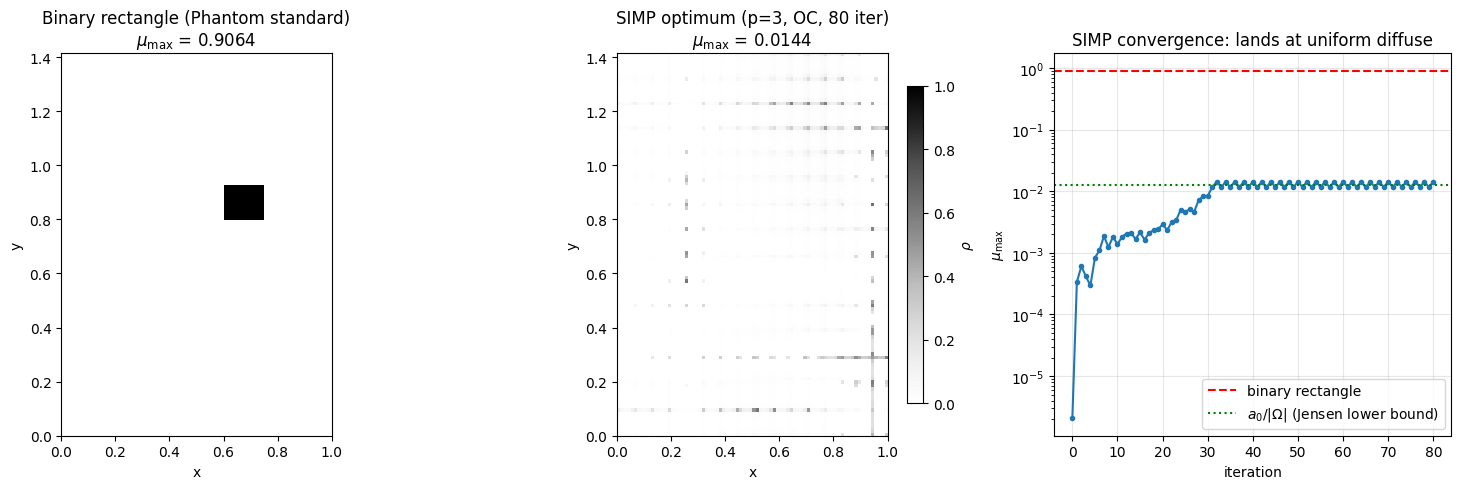

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Left: standard binary rectangle
ax = axes[0]
ax.imshow(rho_std.reshape(nx_el, ny_el).T, origin="lower", extent=[0, L, 0, W],
          cmap="Greys", vmin=0, vmax=1)
ax.set_title(f"Binary rectangle (Phantom standard)\n$\\mu_{{\\max}}$ = {mu_max_of(rho_std):.4f}")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")

# Middle: SIMP optimum at p=3
ax = axes[1]
im = ax.imshow(rho_p3.reshape(nx_el, ny_el).T, origin="lower", extent=[0, L, 0, W],
               cmap="Greys", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.04, label=r"$\rho$")
ax.set_title(f"SIMP optimum (p=3, OC, 80 iter)\n$\\mu_{{\\max}}$ = {hist_p3[-1]:.4f}")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")

# Right: convergence history
ax = axes[2]
ax.semilogy(np.arange(len(hist_p3)), hist_p3, "o-", markersize=3)
ax.axhline(mu_max_of(rho_std), color="red", linestyle="--", label="binary rectangle")
ax.axhline(a_0 / (L*W), color="green", linestyle=":", label=r"$a_0/|\Omega|$ (Jensen lower bound)")
ax.set_xlabel("iteration"); ax.set_ylabel(r"$\mu_{\max}$")
ax.set_title("SIMP convergence: lands at uniform diffuse")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## What to take away

**The SIMP setup generalizes beyond compliance.** The same $K[\rho] = \sum_e \rho_e^p K_e$ algebraic structure appears for any objective that is a function of a parametrized PSD operator. For projection-eigenvalue problems, the element matrices are rank-1 outer products of basis-evaluation vectors. The OC update form, the bisection-on-multiplier solver, and the density-filter regularization all carry over.

**Always check the gradient sign before running OC.** The OC update direction is calibrated for compliance (negative gradient). For objectives with positive gradient, you have to flip the update direction. This is one line of code; misdiagnosing it as a bug or convergence problem can cost you a day. The diagnostic: print $\partial f/\partial \rho_e$ at the initial design; if it's all positive, your monotonicity is opposite to compliance and the OC formula needs adjustment.

**SIMP's binarization is a heuristic, not physics.** It works when increasing $\rho$ helps the objective. When increasing $\rho$ hurts the objective (which happens for any "minimize how much something interacts with the design" problem), the SIMP penalty rewards intermediate density. Continuation in $p$ doesn't fix this — it makes it worse. The fix is to choose a different objective or accept the relaxed (non-binary) optimum.

**No classical minimizer is a feature of the *problem*, not a bug in the solver.** Cox-Lipton 1996 and successors proved that two-phase eigenvalue minimization at fixed measure typically lacks a classical minimizer; the relaxed optimum is intermediate density. We've reproduced this in a Slepian-type setting. The right response to a non-binary SIMP optimum isn't to push harder for binarity — it's to ask whether the formulation is what you actually want, and whether a different objective on the same problem might be well-posed. That's Notebook 5.

**The next notebook** is the constructive complement to this one: a different scalar from the same framework, specifically a *boundary-trace* integral, which factorizes in the sine basis and admits a closed-form gradient. The optimum is non-degenerate, sits in a compact rectangular configuration, and gives a plausible "what gap should I use" recommendation.
